<a href="https://colab.research.google.com/github/ShrimantiGawande/Deep-Learning-/blob/main/LE_NET_5_Exp_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# LE NET - 5 CNN for MNIST classification
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, AveragePooling2D

In [ ]:
#loading MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [ ]:
print ("Training data", x_train.shape)
print ("Testing data", x_test.shape)

Training data (60000, 28, 28)
Testing data (10000, 28, 28)


In [ ]:
#normalise the images
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
#adding the channel dimension
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [ ]:
#creating le net - 5 CNN
model = Sequential([
    #C1 = Convolution
    layers.Conv2D(filters=6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)),
    #P1 = Pooling layer
    layers.AveragePooling2D(pool_size=(2, 2), strides=2),
    #C2 = Convolutional layer 2
    layers.Conv2D(filters=16, kernel_size=(5, 5), activation='tanh'),
    #P2 = Pooling layer 2
    layers.AveragePooling2D(pool_size=(2, 2), strides=2),
    #Flatten
    layers.Flatten(),
    #F3 = Fully connected layer 3
    layers.Dense(units=120, activation='tanh'),
    layers.Dense(units=84, activation='tanh'),
    #Output layer
    layers.Dense(units=10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary ()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from IPython.core import history
#train the model
history = model.fit(x_train, y_train, epochs=10, batch_size = 128, validation_split = 0.1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.8934 - loss: 0.3722 - val_accuracy: 0.9637 - val_loss: 0.1417
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.9582 - loss: 0.1381 - val_accuracy: 0.9732 - val_loss: 0.0991
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9712 - loss: 0.0945 - val_accuracy: 0.9777 - val_loss: 0.0747
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9779 - loss: 0.0717 - val_accuracy: 0.9802 - val_loss: 0.0699
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.9821 - loss: 0.0582 - val_accuracy: 0.9840 - val_loss: 0.0591
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9861 - loss: 0.0459 - val_accuracy: 0.9838 - val_loss: 0.0561
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.9883 - loss: 0.0382 - val_accuracy: 0.9823 - val_loss: 0.0574
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9890 - loss: 0.0351 - 

In [ ]:
#test the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9846 - loss: 0.0466
Test accuracy: 0.9846000075340271


In [ ]:
#making predictions
predictions = model.predict(x_test)
print("Predicted digit", predictions[0].argmax())
print("Actal digit", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predicted digit 7
Actal digit 7


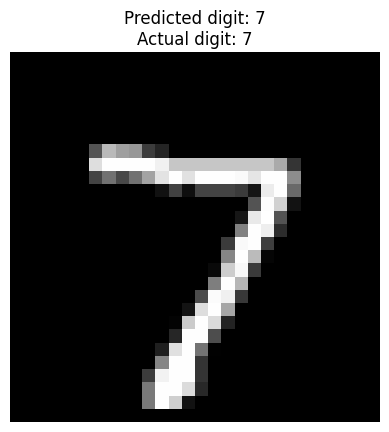

In [ ]:
plt.imshow(x_test[0].reshape(28, 28), cmap='gray')
plt.title(
    f"Predicted digit: {predictions[0].argmax()}\n"
    f"Actual digit: {y_test[0]}"
)
plt.axis('off')
plt.show()
